In [214]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

In [ ]:
# load the dataset and keep only the variables needed for research question 1.
df = pd.read_csv("movies_dataset.csv")

keep_cols = ["id", "title", "release_date", "budget", "revenue", "genres"]
df = df[keep_cols].copy()




In [ ]:
# convert release date to datetime and extract year.
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

In [ ]:
# ensure budget and revenue are numeric values.
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")

In [ ]:
# Convert stored genre strings into Python lists
df["genre_list"] = df["genres"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
) 

In [219]:
# Create release period categories
bins = [1989, 1999, 2009, 2019, 2025]
labels = ["1990s", "2000s", "2010s", "2020-2025"]
df["release_period"] = pd.cut(df["release_year"], bins=bins, labels=labels)

In [ ]:
# Keep only movies with positive budget and revenue values.
df_rq1 = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()

The distribution of box office revenue is strongly right-skewed. The skewness of revenue is about 3.4, which indicates the presence of extreme blockbuster outliers. A logarithmic transformation is used to reduce this skewness and make the distribution more suitable for regression analysis.

In [ ]:
# check skewness of revenue.
df_rq1["revenue"].skew()

np.float64(3.406742872695515)

In [ ]:
# check skewness after the log transformation.
df_rq1["log_revenue"].skew()

np.float64(-1.5618080903149256)

In [ ]:
# apply logarithmic transformation to reduce skewness.
df_rq1["log_budget"] = np.log(df_rq1["budget"])
df_rq1["log_revenue"] = np.log(df_rq1["revenue"])

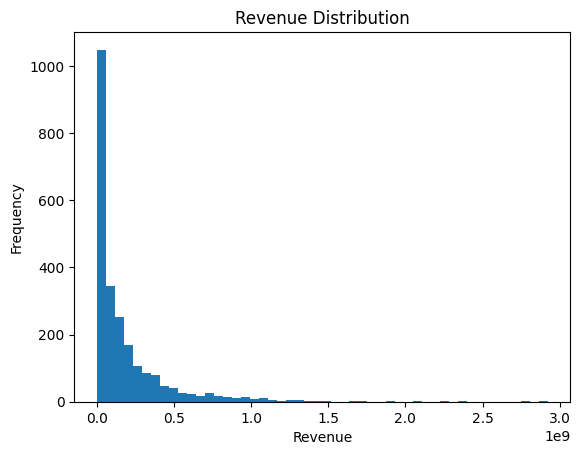

In [253]:
plt.hist(df_rq1["revenue"], bins=50)
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.title("Revenue Distribution")
plt.show()

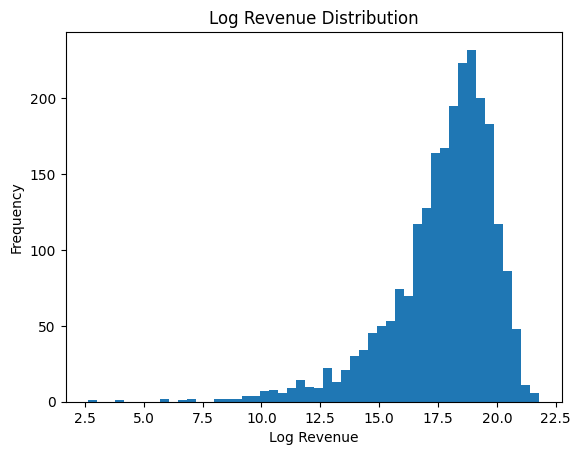

In [254]:
plt.hist(df_rq1["log_revenue"], bins=50)
plt.xlabel("Log Revenue")
plt.ylabel("Frequency")
plt.title("Log Revenue Distribution")
plt.show()

In [ ]:
# compute the correlation between log budget and log revenue.
corr = df_rq1["log_budget"].corr(df_rq1["log_revenue"])
r_squared = corr ** 2

print("Correlation:", corr)
print("R-squared:", r_squared)

Correlation: 0.7357357126069557
R-squared: 0.5413070388052649


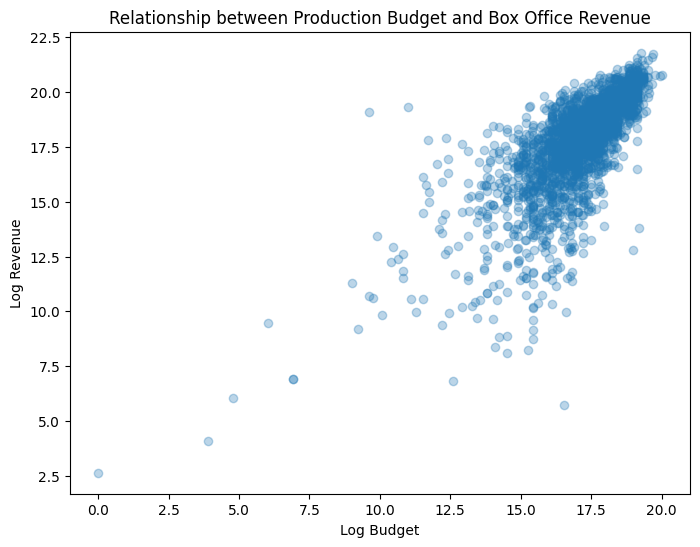

In [ ]:
# visualize relationship between production budget and revenue
plt.figure(figsize=(8, 6))

plt.scatter(
    df_rq1["log_budget"],
    df_rq1["log_revenue"],
    alpha=0.3
)

plt.xlabel("Log Budget")
plt.ylabel("Log Revenue")
plt.title("Relationship between Production Budget and Box Office Revenue")

plt.show()

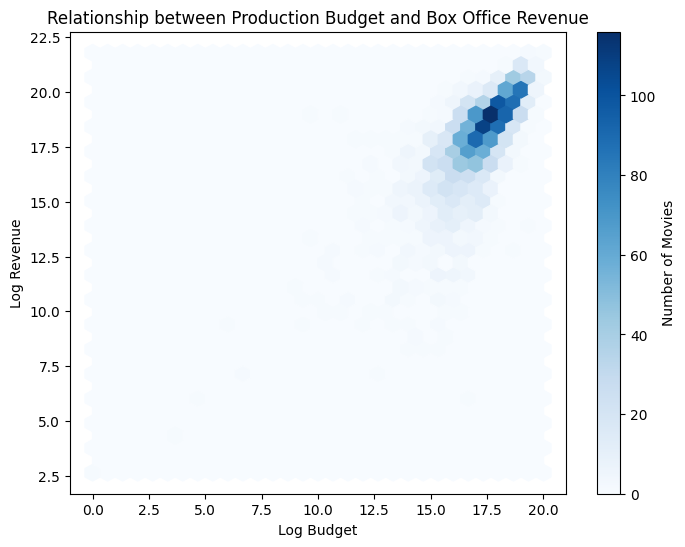

In [270]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    df_rq1["log_budget"],
    df_rq1["log_revenue"],
    gridsize=30,
    cmap="Blues"
)

plt.colorbar(label="Number of Movies")
plt.xlabel("Log Budget")
plt.ylabel("Log Revenue")
plt.title("Relationship between Production Budget and Box Office Revenue")

plt.show()
plt.show()

In [ ]:
# estimate a simple log-log regression of revenue on budget.
def estimate_budget_effect(data):
    x = data["log_budget"].values
    y = data["log_revenue"].values
    X = np.column_stack((np.ones(len(x)), x))
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return beta[0], beta[1]

In [258]:
intercept, budget_effect = estimate_budget_effect(df_rq1)

print("Intercept:", intercept)
print("Budget effect:", budget_effect)

Intercept: 0.045063517608703356
Budget effect: 1.0366854926220976


The analysis indicates a positive relationship between production budget and box office revenue in our sample. The correlation between log budget and log revenue is about 0.74. In the log-log model, a 1% increase in production budget is associated with an estimated 1.04% increase in box office revenue.

In [259]:
# create a genre-level dataset in which movies appear in every listed genre.
df_genres = df_rq1.explode("genre_list").copy()
df_genres = df_genres.rename(columns={"genre_list": "genre"})

In [261]:
# Count movies by genre.
df_genres["genre"].value_counts().head(10)

genre
Drama              969
Action             800
Comedy             767
Thriller           674
Adventure          600
Crime              411
Science Fiction    377
Romance            363
Family             330
Fantasy            330
Name: count, dtype: int64

In [264]:
# Select most common genres for comparison
genres = ["Drama", "Action", "Comedy", "Thriller", "Adventure", "Crime"]

In [265]:
results = []

for g in genres:
    # Filter the dataset for the current genre.
    df_g = df_genres[df_genres["genre"] == g]
    intercept, budget_effect = estimate_budget_effect(df_g)

    results.append({
        "genre": g,
        "n_movies": len(df_g),
        "budget_effect": budget_effect
    })

results_df = pd.DataFrame(results)
results_df

,genre,n_movies,budget_effect
0,Drama,969,1.023161
1,Action,800,1.091115
2,Comedy,767,1.115207
3,Thriller,674,1.027836
4,Adventure,600,1.117504
5,Crime,411,0.989909


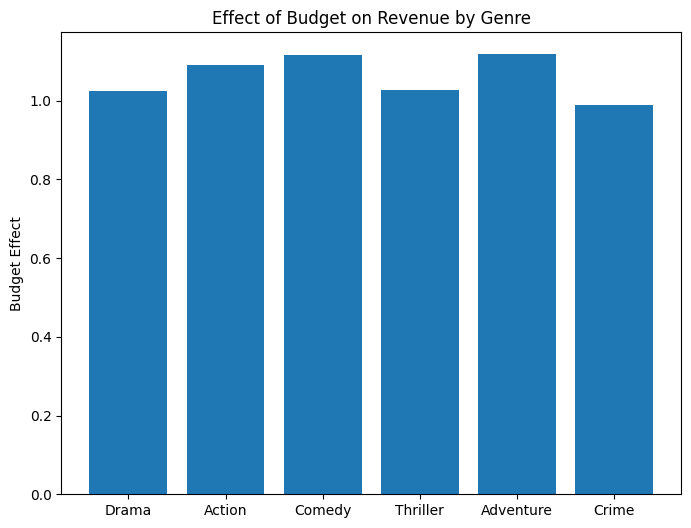

In [267]:
# visualize the budget effect across genres.
plt.figure(figsize=(8, 6))

plt.bar(results_df["genre"], results_df["budget_effect"])

plt.ylabel("Budget Effect")
plt.title("Effect of Budget on Revenue by Genre")

plt.show()

For the genre analysis, movies were included in every genre listed in the dataset. As a result, films with multiple genres appear in more than one genre group, and the genre counts do not sum to the total number of unique movies.

The estimated budget effect differs across film genres. It is highest for adventure and comedy films and lower for crime and drama films. In our sample, this suggests that the association between budget and revenue is not equally strong across genres.

In [268]:
# define time periods for comparison.
periods = ["1990s", "2000s", "2010s", "2020-2025"]

results_period = []

for p in periods:
    # filter movies by release period.
    df_p = df_rq1[df_rq1["release_period"] == p]
    intercept, budget_effect = estimate_budget_effect(df_p)

    results_period.append({
        "period": p,
        "n_movies": len(df_p),
        "budget_effect": budget_effect
    })

results_period_df = pd.DataFrame(results_period)
results_period_df

,period,n_movies,budget_effect
0,1990s,542,0.991316
1,2000s,780,0.973214
2,2010s,765,1.153468
3,2020-2025,286,1.028936


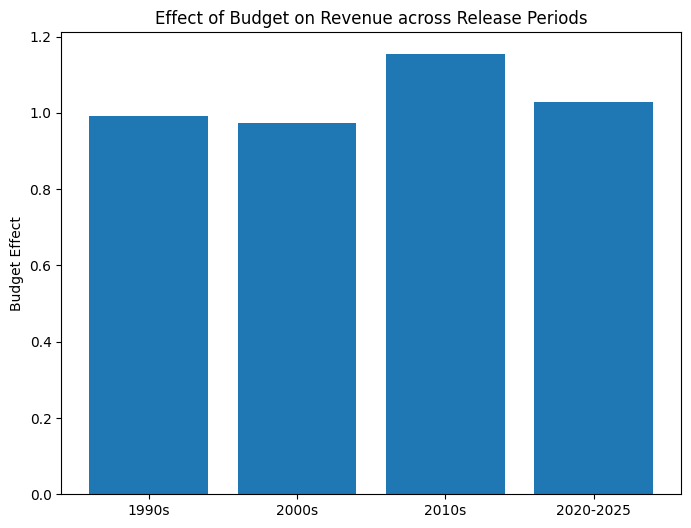

In [231]:
# Visualize budget effect across time periods
plt.figure(figsize=(8,6))

plt.bar(results_period_df["period"], results_period_df["budget_effect"])

plt.ylabel("Budget Effect")
plt.title("Effect of Budget on Revenue across Release Periods")

plt.show()

The estimated budget effect varies across release periods. It is close to proportional in the 1990s and 2000s and highest in the 2010s. In our sample, this suggests that the association between budget and revenue was stronger during the 2010s than in the earlier periods.